<a href="https://colab.research.google.com/github/Storm00212/8-bit-cpu-using-verilog/blob/main/QUESTION_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install commpy

import numpy as np
import matplotlib.pyplot as plt
!pip install komm
import komm


QUESTION A

# GENERATING MAGNITUDE AND FREQUENCY RESPONSE FOR RAISED COSINE MANUALLY THEN COMPARING THEM WITH THE FUNCTIONS IN THE KOMM LIB

# since the raised cosine function has 3 parts i used if else statements to generate the function for different values of t

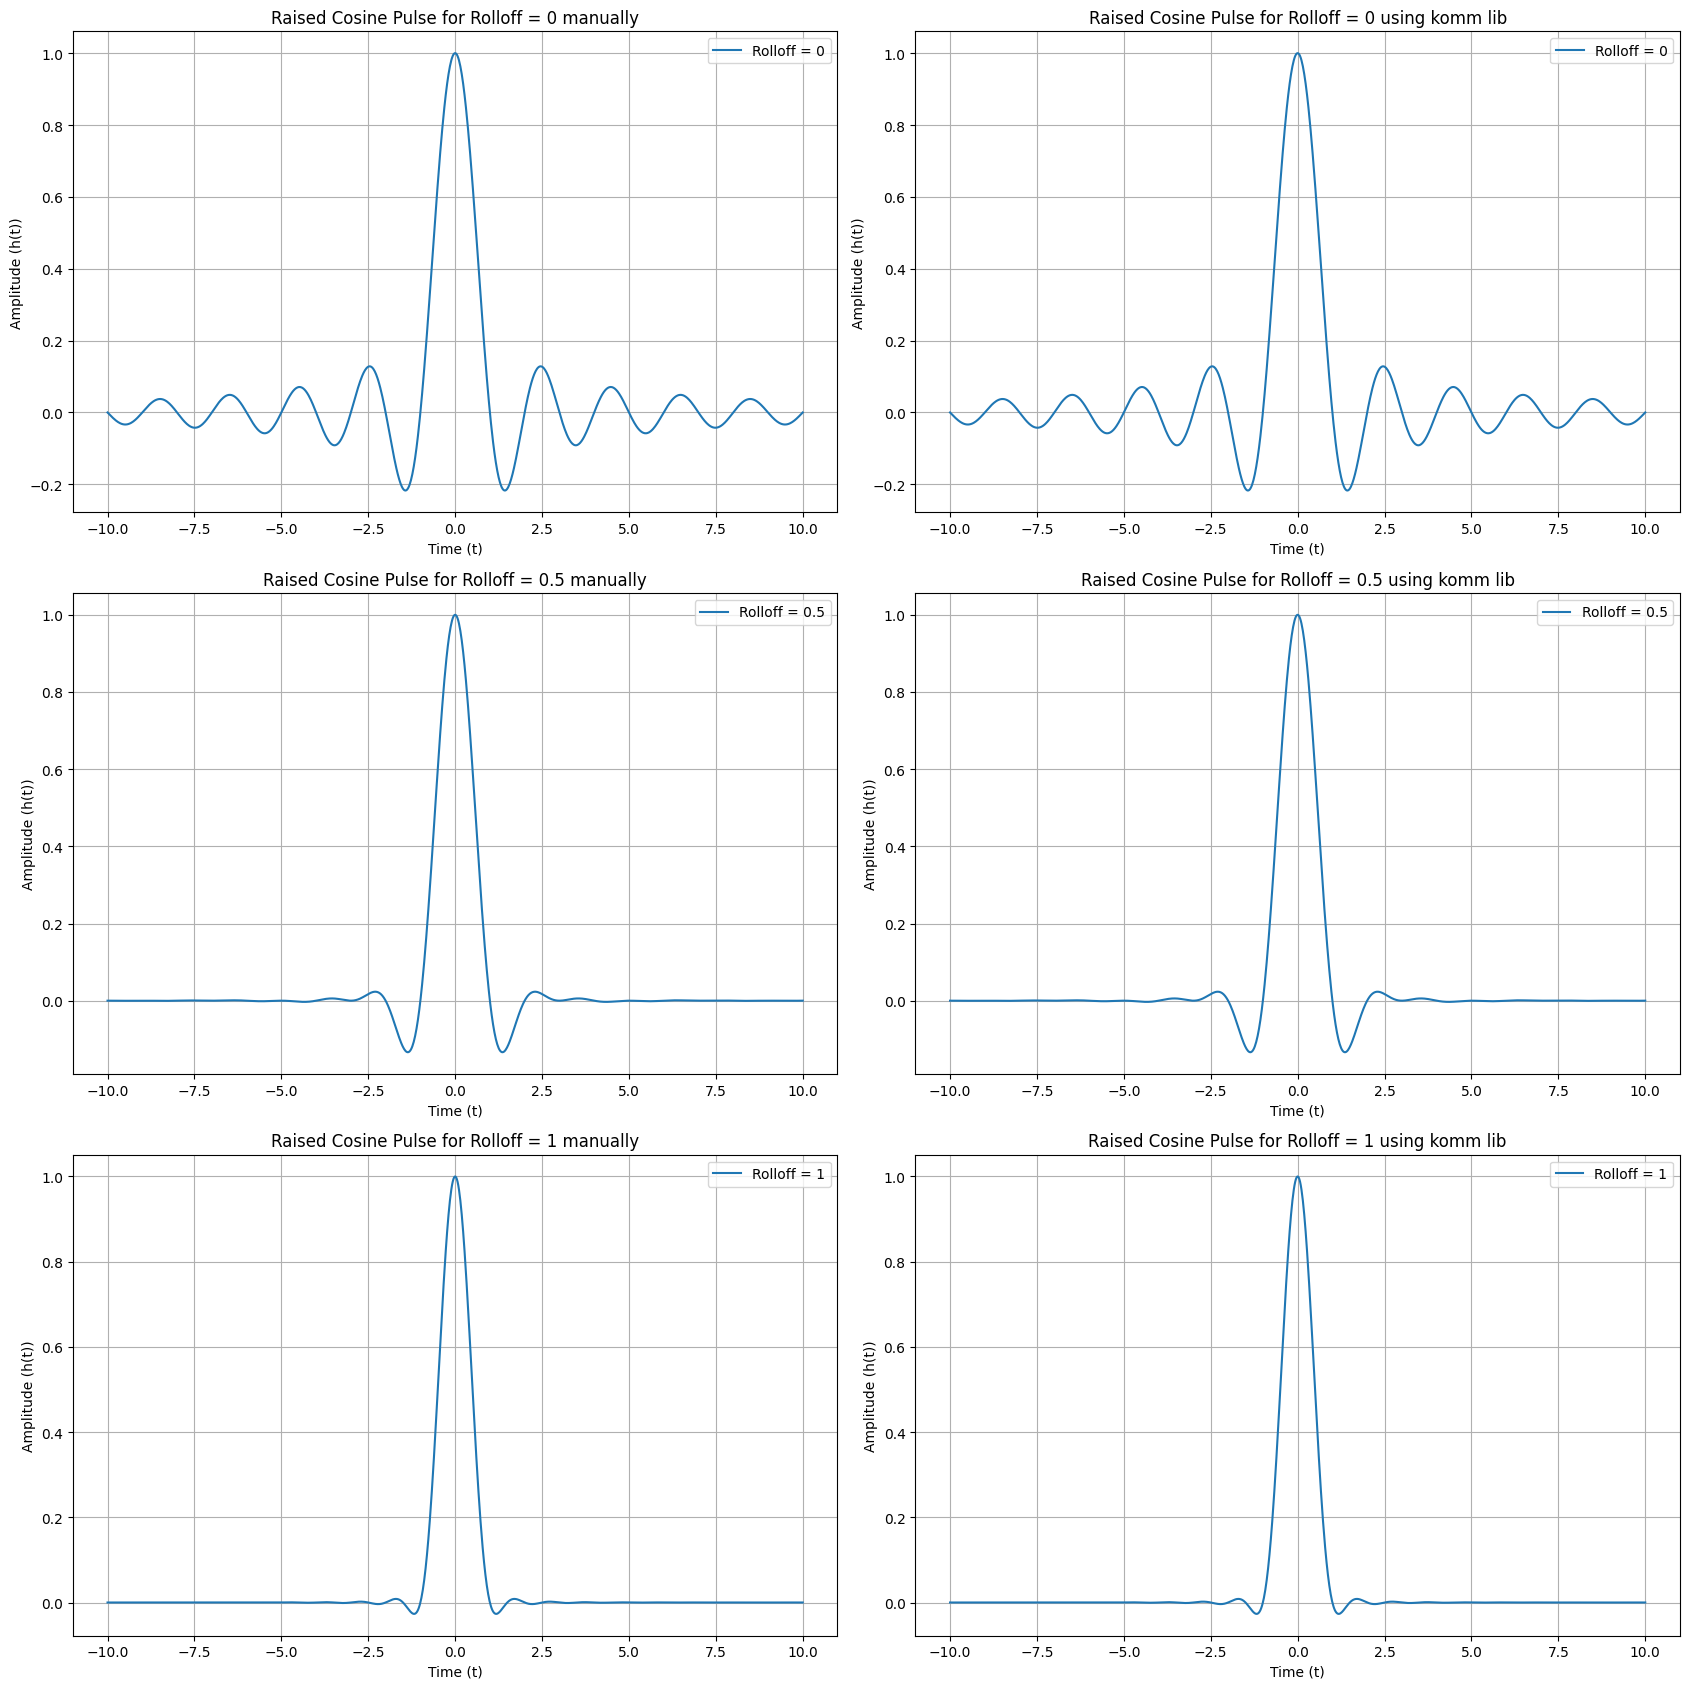

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import komm

# MANUALLY and using compy
Ts = 1
rolloffs = [0, 0.5, 1]

def rc_pulse(t, Ts, B):
    "computes the rc function for each point t"
    # Ensure t is a numpy array so we handle this well cuz t is contonuous
    t_array = np.asarray(t, dtype=float)

    # Handle the special case where rolloff factor B is 0 (ideal sinc filter)
    if B == 0:
        return (1 / Ts) * np.sinc(t_array / Ts)

    with np.errstate(divide='ignore', invalid='ignore'):
        # numerator and denominator for the general formula
        numerator = np.cos((np.pi * B * t_array) / Ts)
        denominator = 1 - ((2 * B * t_array) / Ts)**2

        # Calculate b_vals, np.sinc handles t_array=0 correctly
        b_vals = (1 / Ts) * np.sinc(t_array / Ts)

        # Initialize h_vals. Use np.divide to handle division by zero for 'a_vals' gracefully
        # Points where denominator is zero (special cases) will be overwritten later.
        a_vals = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
        h_vals = a_vals * b_vals

        # Apply specific conditions to overwrite h_vals at special points

        # Condition 1: t == 0
        zero_mask = (t_array == 0)
        h_vals[zero_mask] = 1 / Ts

        # Condition 2: t == +/- Ts / (2 * B)
        # These are the points where 'denominator' would be zero in the general formula.
        abs_Ts_2B = Ts / (2 * B)
        # Use np.isclose for robust floating-point comparison for these special points
        special_point_mask = np.isclose(t_array, abs_Ts_2B) | np.isclose(t_array, -abs_Ts_2B)
        h_vals[special_point_mask] = (1 / (2 * Ts)) * np.sinc(1 / (2 * B))

    return h_vals

# 2 cols to compare side by side.
fig, axes = plt.subplots(3, 2, figsize=(17, 17))
t = np.linspace(-10, 10, 1000)
# thought i'd do a side by side comparison
for i, rolloff in enumerate(rolloffs):
    h = rc_pulse(t, Ts, rolloff)
    #  RaisedCosinePulse object with the rolloff factor
    K_pulse_filter = komm.RaisedCosinePulse(rolloff)
    # Get the impulse response values by calling the pulse filter object with the time array
    K_values = K_pulse_filter.waveform(t)
    axes[i,0].plot(t, h, label=f'Rolloff = {rolloff}')
    axes[i,0].set_title(f'Raised Cosine Pulse for Rolloff = {rolloff} manually')
    axes[i,0].set_xlabel('Time (t)')
    axes[i,0].set_ylabel('Amplitude (h(t))')
    axes[i,0].legend()
    axes[i,0].grid(True)

    axes[i,1].plot(t, K_values, label=f'Rolloff = {rolloff}')
    axes[i,1].set_title(f'Raised Cosine Pulse for Rolloff = {rolloff} using komm lib')
    axes[i,1].set_xlabel('Time (t)')
    axes[i,1].set_ylabel('Amplitude (h(t))')
    axes[i,1].legend()
    axes[i,1].grid(True)

plt.tight_layout()
plt.show()

# NOW FOR THE FOURIER TRANSFORMS

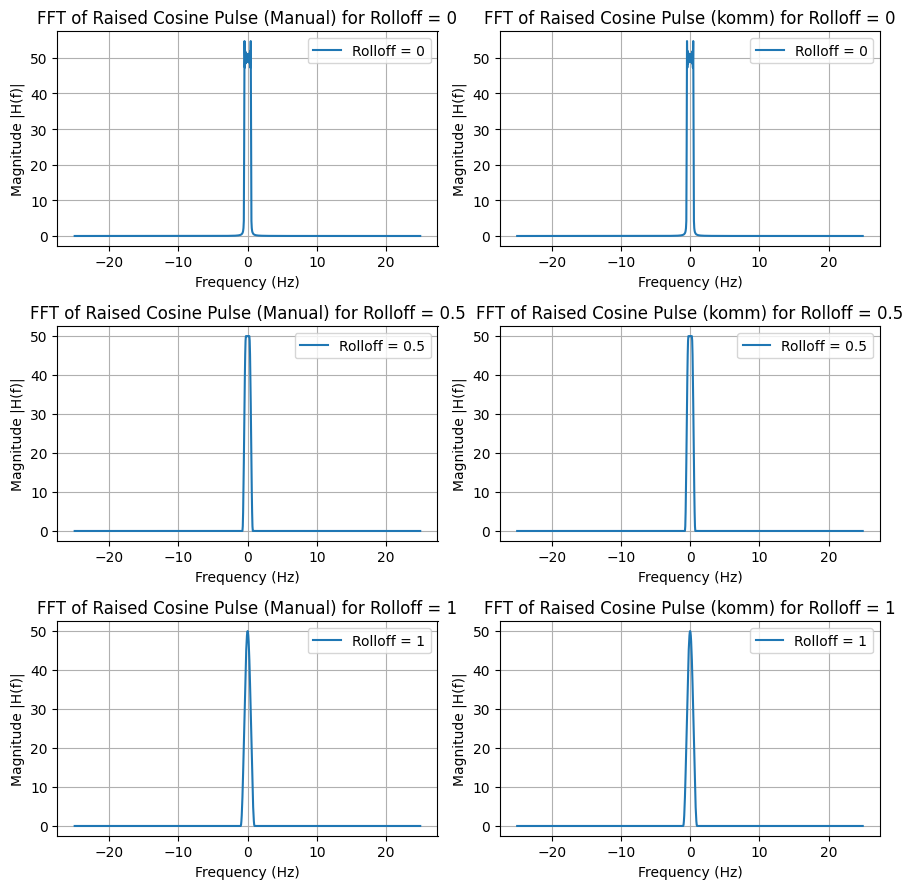

In [39]:
# just taking fourier transforms of the functions above and iterating them for the 3 rolloffs.
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
t = np.linspace(-10, 10, 1000)
dt = t[1] - t[0] #interval for frequency axis

for i, rolloff in enumerate(rolloffs):
    # Manual pulse FFT
    h = rc_pulse(t, Ts, rolloff)
    h_fft = np.fft.fftshift(np.fft.fft(h))

    # komm library pulse FFT
    komm_pulse_filter = komm.RaisedCosinePulse(rolloff) # Instantiate for current rolloff
    K_values_for_fft = komm_pulse_filter.waveform(t) # Get waveform from instance(used docs for this)
    K_values_fft = np.fft.fftshift(np.fft.fft(K_values_for_fft))#shift for better waveform

    frequency = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))

    # Plot for manual pulse FFT
    axes[i,0].plot(frequency, np.abs(h_fft), label=f'Rolloff = {rolloff}')
    axes[i,0].set_title(f'FFT of Raised Cosine Pulse (Manual) for Rolloff = {rolloff}')
    axes[i,0].set_xlabel('Frequency (Hz)')
    axes[i,0].set_ylabel('Magnitude |H(f)|')
    axes[i,0].legend()
    axes[i,0].grid(True)

    # Plot for komm library pulse FFT
    axes[i,1].plot(frequency, np.abs(K_values_fft), label=f'Rolloff = {rolloff}')
    axes[i,1].set_title(f'FFT of Raised Cosine Pulse (komm) for Rolloff = {rolloff}')
    axes[i,1].set_xlabel('Frequency (Hz)')
    axes[i,1].set_ylabel('Magnitude |H(f)|')
    axes[i,1].legend()
    axes[i,1].grid(True)

plt.tight_layout()
plt.show()

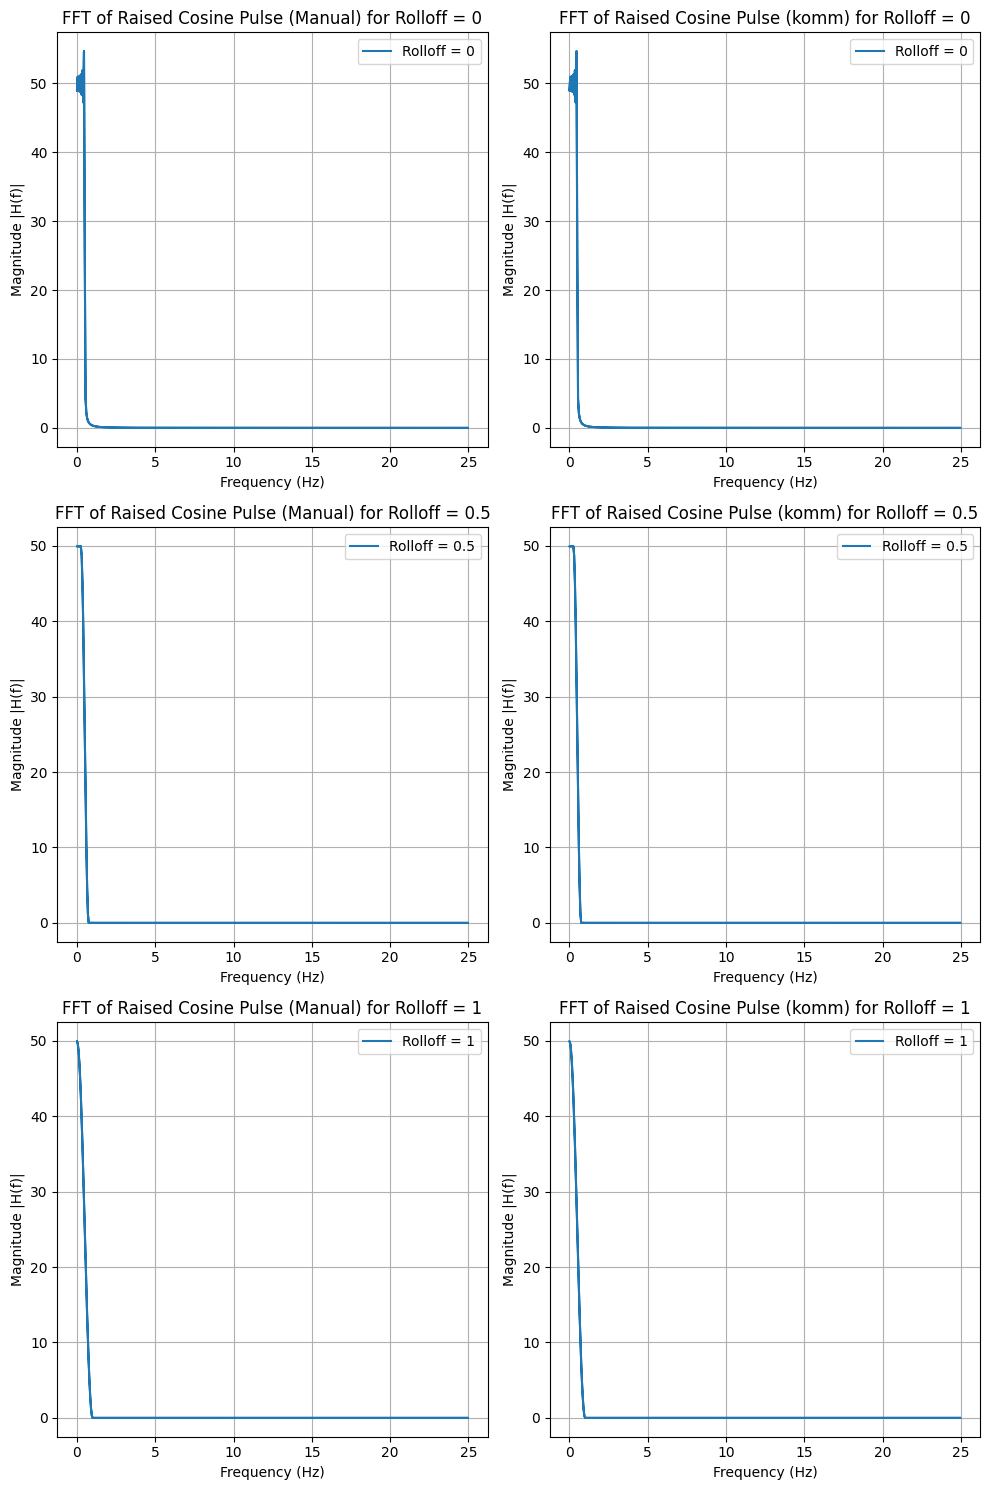

In [47]:
# for absolute frequency justget magnitude of frequency using np.abs(frequency)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
t = np.linspace(-10, 10, 1000)
dt = t[1] - t[0]

for i, rolloff in enumerate(rolloffs):

    h = rc_pulse(t, Ts, rolloff)
    h_fft = np.fft.fftshift(np.fft.fft(h))


    komm_pulse_filter = komm.RaisedCosinePulse(rolloff)
    K_values_for_fft = komm_pulse_filter.waveform(t)
    K_values_fft = np.fft.fftshift(np.fft.fft(K_values_for_fft))

    frequency = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))


    axes[i,0].plot(np.abs(frequency), np.abs(h_fft), label=f'Rolloff = {rolloff}')
    axes[i,0].set_title(f'FFT of Raised Cosine Pulse (Manual) for Rolloff = {rolloff}')
    axes[i,0].set_xlabel('Frequency (Hz)')
    axes[i,0].set_ylabel('Magnitude |H(f)|')
    axes[i,0].legend()
    axes[i,0].grid(True)


    axes[i,1].plot(np.abs(frequency), np.abs(K_values_fft), label=f'Rolloff = {rolloff}')
    axes[i,1].set_title(f'FFT of Raised Cosine Pulse (komm) for Rolloff = {rolloff}')
    axes[i,1].set_xlabel('Frequency (Hz)')
    axes[i,1].set_ylabel('Magnitude |H(f)|')
    axes[i,1].legend()
    axes[i,1].grid(True)

plt.tight_layout()
plt.show()

# as you can see for both manual and komm, the waveform is the same so we can proceed with either one of the 2